# GD - Homework 2

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import time

## 3. Implement GD, Polyak GD, Nesterov GD, and AdaGrad GD.

* GD: xk+1 = xk−γ∇f (xk )
* Polyak: xk+1 = xk−γ∇f (xk ) + µ(xk−xk−1)
* Nesterov: xk+1 = xk−γ∇f xk + µ(xk−xk−1) + µ(xk−xk−1)
* AdaGrad: xk+1 = xk−γDk ·∇f (xk )

In [ ]:
#NUMERIC helper for gradient (for harder problems where we don't have an analytical gradient)
def get_grad(f, x, eps=1e-5):
    g = np.zeros_like(x)
    for i in range(len(x)):
        x1, x2 = x.copy(), x.copy()
        x1[i] += eps; x2[i] -= eps
        g[i] = (f(x1) - f(x2)) / (2 * eps)
    return g

In [22]:
def gradient_descent(func, x0, gamma, n_iters, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(func, x)

    x = np.array(x0, dtype=float)
    history = [x.copy()]
    for _ in range(n_iters):
        grad = grad_f(x)
        x = x - gamma * grad
        history.append(x.copy())
    return np.array(history)

def polyak_gd(func, x0, gamma, mu, n_iters, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(func, x)

    x = np.array(x0, dtype=float)
    x_prev = x.copy()
    history = [x.copy()]
    for i in range(n_iters):
        grad = grad_f(x)
        if i == 0:
            #standard GD for first iter
            x_next = x - gamma * grad
        else:
            x_next = x - gamma * grad + mu * (x - x_prev)   
        x_prev = x.copy()
        x = x_next.copy()
        history.append(x.copy())  
    return np.array(history)

def nesterov_gd(func, x0, gamma, mu, n_iters, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(func, x)

    x = np.array(x0, dtype=float)
    x_prev = x.copy()
    history = [x.copy()]
    for i in range(n_iters):
        if i == 0:
            #standard GD
            x_next = x - gamma * grad_f(x)
        else:
            #momentum first
            x_lookahead = x + mu * (x - x_prev)
            x_next = x - gamma * grad_f(x_lookahead) + mu * (x - x_prev)           
        x_prev = x.copy()
        x = x_next.copy()
        history.append(x.copy())
    return np.array(history)

def adagrad_gd(func, x0, gamma, n_iters, epsilon=1e-8, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(func, x)

    x = np.array(x0, dtype=float)
    history = [x.copy()]
    # Cumulative sum of squared gradients for each coordinate
    sq_grad_sum = np.zeros_like(x)
    for _ in range(n_iters):
        grad = grad_f(x)
        sq_grad_sum += grad**2
        #Dk mtx
        D_k = 1.0 / (np.sqrt(sq_grad_sum) + epsilon)
        # component-wise update
        x = x - gamma * D_k * grad
        history.append(x.copy())
    return np.array(history)

**TEST:** on function $f(x,y)=x^2 + 5y^2$ with minimum at (0,0)... the same function as in the notes (fig 15,16)

**GRADIENT:** $\nabla f(x,y) = (2x, 10y)$. The Hessian has eigenvalues $\alpha = 2$ and $\beta = 10$.

**GD param:** optimal LR for a quadratic is $\gamma = \frac{2}{\alpha + \beta} = \frac{2}{12} \approx 0.166$.  

**Polyak params:** $\gamma = \frac{4}{(\sqrt{\alpha} + \sqrt{\beta})^2}$ and $\mu = \left(\frac{\sqrt{\beta} - \sqrt{\alpha}}{\sqrt{\beta} + \sqrt{\alpha}}\right)^2$. So we get $\gamma \approx 0.19$ and $\mu \approx 0.15$

**Nesterov params:** $\gamma = \frac{1}{\beta}$ and $\mu = \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}$, where $\kappa = \frac{\beta}{\alpha}$... (theorem 5.3). So this gives us $\gamma = 0.1$ and $\mu \approx 0.382$

**AdaGrad param:** standard learning rate ($\gamma = 1.0$) because AdaGrad independently weights each coordinate by accumulating past gradients, meaning it adapts its own step size.

In [24]:
def f(v):
    x, y = v
    return x**2 + 5 * y**2

def grad_f(v):
    x, y = v
    return np.array([2*x, 10*y])

#initial params
x0 = [1.0, 1.0]
n_iterations = 10

#optimal params (based on alpha=2, beta=10)
gamma_gd = 1/6
gamma_polyak = 4 / (np.sqrt(2) + np.sqrt(10))**2
mu_polyak = ((np.sqrt(10) - np.sqrt(2)) / (np.sqrt(10) + np.sqrt(2)))**2
kappa = 10 / 2
gamma_nesterov = 1 / 10
mu_nesterov = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)

hist_gd = gradient_descent(f, x0, gamma=gamma_gd, n_iters=n_iterations, grad_f=grad_f)
hist_polyak = polyak_gd(f, x0, gamma=gamma_polyak, mu=mu_polyak, n_iters=n_iterations, grad_f=grad_f)
hist_nesterov = nesterov_gd(f, x0, gamma=gamma_nesterov, mu=mu_nesterov, n_iters=n_iterations, grad_f=grad_f)
hist_adagrad = adagrad_gd(f, x0, gamma=1.0, n_iters=n_iterations, grad_f=grad_f)

print("Final positions after 10 iterations (target: [0.0, 0.0]):\n")
print(f"Standard GD: {hist_gd[-1]} | f(x,y) = {f(hist_gd[-1]):.6f}")
print(f"Polyak GD:   {hist_polyak[-1]} | f(x,y) = {f(hist_polyak[-1]):.6f}")
print(f"Nesterov GD: {hist_nesterov[-1]} | f(x,y) = {f(hist_nesterov[-1]):.6f}")
print(f"AdaGrad GD:  {hist_adagrad[-1]} | f(x,y) = {f(hist_adagrad[-1]):.6f}")

Final positions after 10 iterations (target: [0.0, 0.0]):

Standard GD: [0.01734153 0.01734153] | f(x,y) = 0.001804
Polyak GD:   [0.00047467 0.00097968] | f(x,y) = 0.000005
Nesterov GD: [0.01457909 0.        ] | f(x,y) = 0.000213
AdaGrad GD:  [9.76562404e-84 1.00000069e-90] | f(x,y) = 0.000000


## 4. Find, describe, and implement Adam GD.

Adam (Adaptive Moment Estimation) combines the heavy-ball momentum from Polyak/Nesterov with the adaptive, coordinate-wise scaling of AdaGrad/RMSProp.  Instead of just adapting the learning rate based on the sum of past squared gradients (like AdaGrad, which eventually dampens the process too much ), Adam keeps an exponentially decaying average of past squared gradients. It also keeps an exponentially decaying average of past gradients (like momentum).

At each step k it calculates:
* First moment (mean): $m_k = \beta_1 m_{k-1} + (1 - \beta_1) \nabla f(x_{k-1})$
* Second moment (var): $v_k = \beta_2 v_{k-1} + (1 - \beta_2) (\nabla f(x_{k-1}))^2$

Bias correction step (to fix biasness toward 0):
* $\hat{m}_k = \frac{m_k}{1 - \beta_1^k}$
* $\hat{v}_k = \frac{v_k}{1 - \beta_2^k}$

Update rule:
$x_k = x_{k-1} - \gamma \frac{\hat{m}_k}{\sqrt{\hat{v}_k} + \epsilon}$

Params:
* $\gamma$ - global LR (npr 0.001)
* $\beta_1$ - exponential decay rate for first moment (npr 0.9)
* $\beta_2$ - exponential decay rate for second moment (npr 0.999)
* $\epsilon$ - prevent divison by 0

In [25]:
def adam_gd(func, x0, gamma=0.1, n_iters=100, beta1=0.9, beta2=0.999, epsilon=1e-8, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(func, x)
    
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    #first and second moments to zero
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    
    for k in range(1, n_iters + 1):
        grad = grad_f(x)
        #update biased first moment
        m = beta1 * m + (1 - beta1) * grad
        #ppdate biased second raw moment
        v = beta2 * v + (1 - beta2) * (grad**2)
        #compute bias-corrected first moment estimate
        m_hat = m / (1 - beta1**k)
        #compute bias-corrected second raw moment estimate
        v_hat = v / (1 - beta2**k)
        
        # update params
        x = x - gamma * m_hat / (np.sqrt(v_hat) + epsilon)
        history.append(x.copy())
        
    return np.array(history)

In [26]:
def f(v):
    x, y = v
    return x**2 + 5 * y**2

def grad_f(v):
    x, y = v
    return np.array([2*x, 10*y])

#initial params
x0 = [1.0, 1.0]
n_iterations = 100

#use LR of 0.5 for faster convergence on this simple quadratic
hist_adam = adam_gd(f, x0, gamma=0.5, n_iters=n_iterations, grad_f=grad_f)

print("Final position after 100 iterations (target: [0.0, 0.0]):\n")
print(f"Adam GD: {hist_adam[-1]} | f(x,y) = {f(hist_adam[-1]):.10f}")

Final position after 100 iterations (target: [0.0, 0.0]):

Adam GD: [-0.00434583 -0.00434583] | f(x,y) = 0.0001133174


## 5. Implement the Newton method and BFGS

NEWTON: $x_{k+1} = x_k - (\nabla^2 f(x_k))^{-1} \nabla f(x_k)$ 

BFGS: $B_{k+1} = B_k - \frac{\delta \gamma^T B_k + B_k \gamma \delta^T}{\delta^T \gamma} + \left(1 + \frac{\gamma^T B_k \gamma}{\delta^T \gamma}\right) \frac{\delta \delta^T}{\delta^T \gamma}$   

In [ ]:
#NUMERIC helper for hessian
def get_hess(f, x, eps=1e-5):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x1, x2, x3, x4 = x.copy(), x.copy(), x.copy(), x.copy()
            x1[i] += eps; x1[j] += eps
            x2[i] += eps; x2[j] -= eps
            x3[i] -= eps; x3[j] += eps
            x4[i] -= eps; x4[j] -= eps
            H[i,j] = (f(x1) - f(x2) - f(x3) + f(x4)) / (4 * eps * eps)
    
    #check if PD, if not, apply modification
    eigvals = np.linalg.eigvalsh(H)
    if np.any(eigvals <= 0):
        H += (abs(np.min(eigvals)) + 1e-4) * np.eye(n)
    return H

In [27]:
#LINE SEARCH helper
def line_search(f, x, direction, grad):
    alpha = 1.0
    c = 1e-4
    rho = 0.5
    # Armijo condition backtracking
    while f(x + alpha * direction) > f(x) + c * alpha * np.dot(grad, direction):
        alpha *= rho
        if alpha < 1e-8: break # prevent infinite loops
    return alpha

In [28]:
def newton_method(func, x0, n_iters=10, grad_f=None, hessian_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(func, x)
    if hessian_f is None: hessian_f = lambda x: get_hess(func, x)

    x = np.array(x0, dtype=float)
    history = [x.copy()]
    for _ in range(n_iters):
        grad = grad_f(x)
        if np.linalg.norm(grad) < 1e-6: break # converged
        H = hessian_f(x)
        #get direction of the step
        dir = -np.linalg.solve(H, grad)

        #apply line search
        alpha = line_search(func, x, dir, grad)
        x = x + alpha * dir
        history.append(x.copy())
        
    return np.array(history)


def bfgs_method(func, x0, n_iters=20, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(func, x)

    x = np.array(x0, dtype=float)
    n = len(x)
    #initialize B_0 as I (initial guess for inverse hessian)
    B = np.eye(n) 
    history = [x.copy()]
    
    for _ in range(n_iters):
        grad = grad_f(x)
        if np.linalg.norm(grad) < 1e-6: break
        #step direction
        step_dir = -np.dot(B, grad)

        #apply line search
        alpha = line_search(func, x, step_dir, grad)
        x_next = x + alpha * step_dir
        grad_next = grad_f(x_next)
        
        delta = x_next - x      #step diff
        gamma = grad_next - grad    #gradient diff
        #denominator
        denom = np.dot(delta, gamma)
        #avoid division by zero
        if denom > 1e-10:
            term1 = (np.outer(delta, gamma) @ B + B @ np.outer(gamma, delta)) / denom
            scalar_part = 1.0 + np.dot(gamma, B @ gamma) / denom
            term2 = scalar_part * (np.outer(delta, delta) / denom)
            #rank-2 update of the inverse hessian approx
            B = B - term1 + term2
            
        x = x_next.copy()
        history.append(x.copy())
        
    return np.array(history)

Again test on quadratic: $f(x,y) = x^2 + 5y^2$

In [30]:
def f(v):
    x, y = v
    return x**2 + 5 * y**2

def grad_f(v):
    x, y = v
    return np.array([2*x, 10*y])

def hessian_f(v):
    return np.array([[2, 0], 
                     [0, 10]])

x0 = [1.0, 1.0]

#newton
hist_newton = newton_method(f, x0, n_iters=5, grad_f=grad_f, hessian_f=hessian_f)

#BFGS
hist_bfgs = bfgs_method(f, x0, n_iters=20, grad_f=grad_f)

print("NEWTON:")
print(f"Iter 0: {hist_newton[0]} | f(x) = {f(hist_newton[0]):.4f}")
print(f"Iter 1: {hist_newton[1]} | f(x) = {f(hist_newton[1]):.4f}")
print(f"Iter 5: {hist_newton[-1]} | f(x) = {f(hist_newton[-1]):.4f}\n")

print("BFGS METHOD:")
print(f"Iter 0: {hist_bfgs[0]} | f(x) = {f(hist_bfgs[0]):.4f}")
print(f"Iter 1: {hist_bfgs[1]} | f(x) = {f(hist_bfgs[1]):.4f}")
print(f"Iter 5: {hist_bfgs[5]} | f(x) = {f(hist_bfgs[5]):.6f}")
print(f"Iter 20: {hist_bfgs[-1]} | f(x) = {f(hist_bfgs[-1]):.10f}")

NEWTON:
Iter 0: [1. 1.] | f(x) = 6.0000
Iter 1: [0. 0.] | f(x) = 0.0000
Iter 5: [0. 0.] | f(x) = 0.0000

BFGS METHOD:
Iter 0: [1. 1.] | f(x) = 6.0000
Iter 1: [ 0.75 -0.25] | f(x) = 0.8750
Iter 5: [-2.74263778e-06  4.57960411e-07] | f(x) = 0.000000
Iter 20: [ 1.66389840e-08 -4.75759014e-10] | f(x) = 0.0000000000


We can see that the Newton method converges instantly in one step - since our function is perfectly quadratic. BFGS method takes longer but also approaches the minimum very fast as B matrix is updated.

**Choice of $\alpha$**:

In notes it is said:

A line search is typically performed by verifying the Wolfe (or sometimes Armijo) conditions for a chosen α and then adjusting α if necessary. So first I tried solving this problem with $\alpha$ fixed at 0.2, which also made the BFGS converge just a bit slower. Then because of problem 6, I have rewritten this function to now use line search helper with Armijo condition to dynamically adjust $\alpha$.

## 6. Compare the methods of 3., 4, and 5. on:

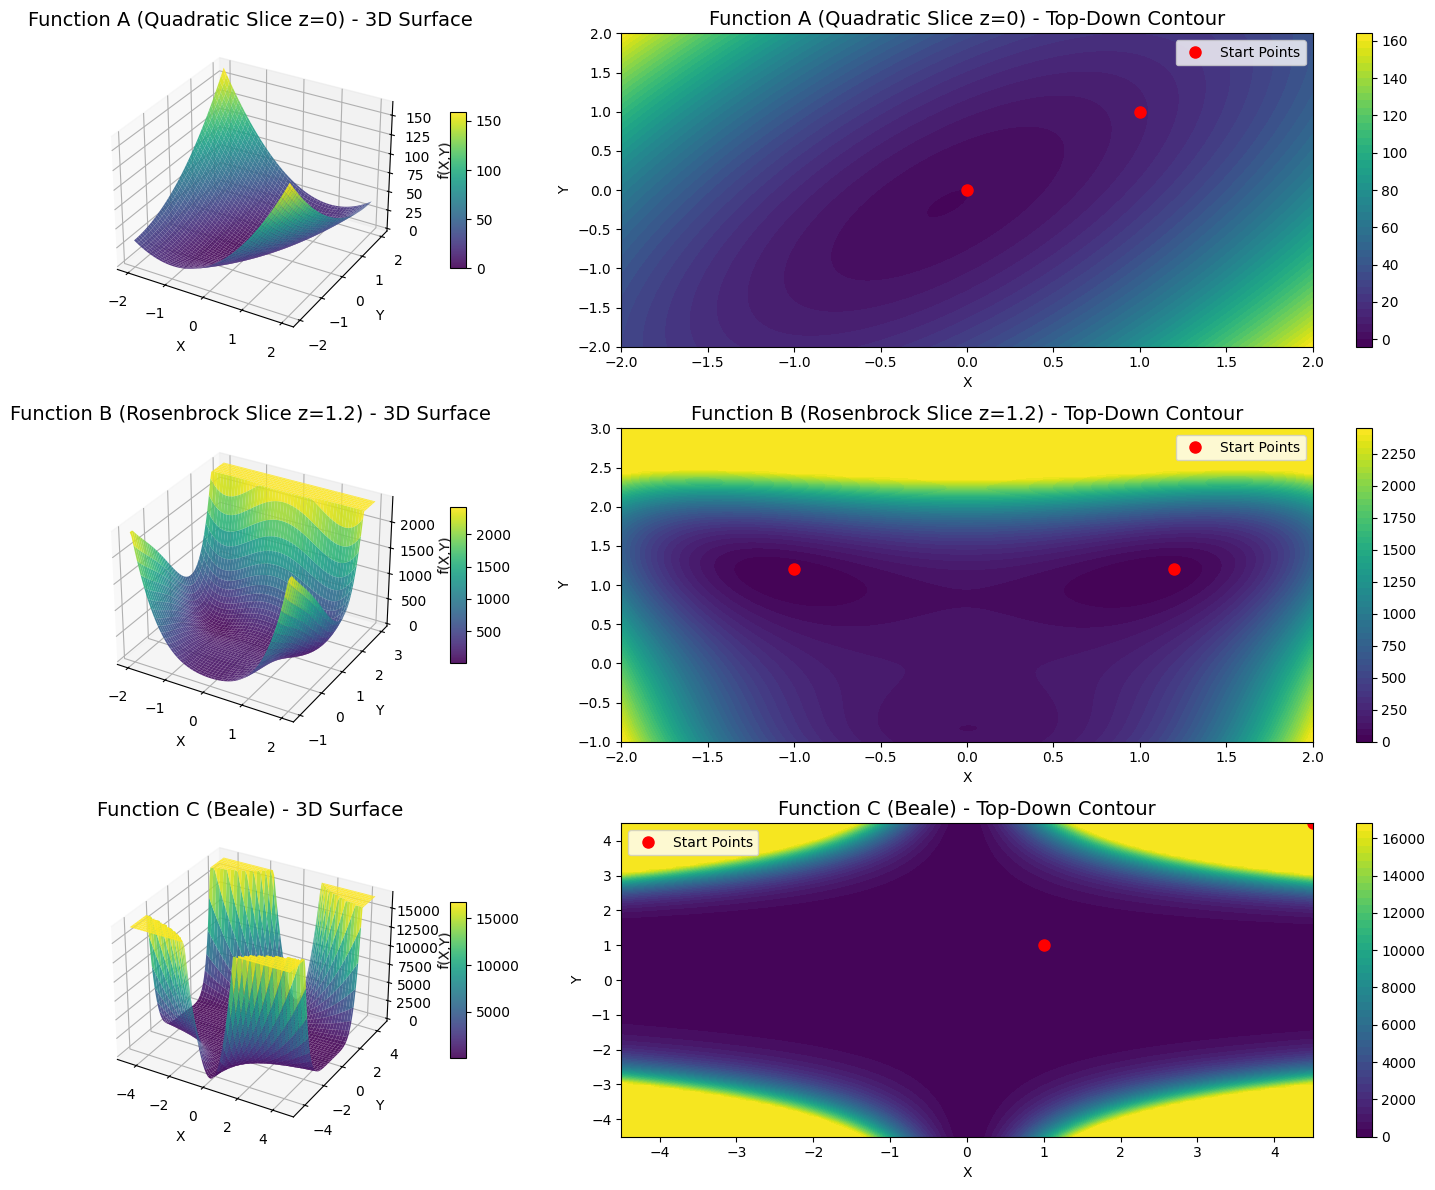

In [34]:
# --- 1. Define the plotting versions of the functions ---
# For A and B, we hold z constant to create a 3D surface plot (2 inputs, 1 output)
def plot_func_a(x, y, z=0):
    return (x - z)**2 + (2*y + z)**2 + (4*x - 2*y + z)**2 + x + y

def plot_func_b(x, y, z=1.2): # z=1.2 matches your Rosenbrock starting point
    return (x - 1)**2 + (y - 1)**2 + 100*(y - x**2)**2 + 100*(z - y**2)**2

def plot_func_c(x, y):
    return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

# --- 2. Setup the plotting grids ---
# We define the range (x and y limits) for each function to best show its features
grids = {
    "Function A (Quadratic Slice z=0)": (np.linspace(-2, 2, 100), np.linspace(-2, 2, 100), plot_func_a),
    "Function B (Rosenbrock Slice z=1.2)": (np.linspace(-2, 2, 100), np.linspace(-1, 3, 100), plot_func_b),
    "Function C (Beale)": (np.linspace(-4.5, 4.5, 100), np.linspace(-4.5, 4.5, 100), plot_func_c)
}

# --- 3. Generate the Plots ---
fig = plt.figure(figsize=(18, 12))

plot_idx = 1
for title, (x_range, y_range, func) in grids.items():
    X, Y = np.meshgrid(x_range, y_range)
    Z = func(X, Y)
    
    # Clip extreme values for B and C so the plots don't stretch to infinity
    if "Rosenbrock" in title or "Beale" in title:
        Z = np.clip(Z, 0, np.percentile(Z, 85))
    
    # 3D Surface Plot
    ax3d = fig.add_subplot(3, 2, plot_idx, projection='3d')
    surf = ax3d.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor='none', alpha=0.9)
    ax3d.set_title(f"{title} - 3D Surface", fontsize=14)
    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('f(X,Y)')
    fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    # 2D Contour Plot (Top-down view of the gradients)
    ax2d = fig.add_subplot(3, 2, plot_idx + 1)
    contour = ax2d.contourf(X, Y, Z, levels=50, cmap=cm.viridis)
    ax2d.set_title(f"{title} - Top-Down Contour", fontsize=14)
    ax2d.set_xlabel('X')
    ax2d.set_ylabel('Y')
    fig.colorbar(contour, ax=ax2d)
    
    # Plot the starting points used in your homework
    if "Function A" in title:
        ax2d.plot([0, 1], [0, 1], 'ro', markersize=8, label='Start Points')
    elif "Function B" in title:
        ax2d.plot([1.2, -1], [1.2, 1.2], 'ro', markersize=8, label='Start Points')
    elif "Function C" in title:
        ax2d.plot([1, 4.5], [1, 4.5], 'ro', markersize=8, label='Start Points')
    
    ax2d.legend()
    plot_idx += 2

plt.tight_layout()
plt.show()

In [19]:
import time

In [31]:
def func_a(v):
    x, y, z = v
    return (x - z)**2 + (2*y + z)**2 + (4*x - 2*y + z)**2 + x + y

def func_b(v):
    x, y, z = v
    return (x - 1)**2 + (y - 1)**2 + 100*(y - x**2)**2 + 100*(z - y**2)**2

def func_c(v):
    x, y = v
    return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

In [32]:
tasks = [
    ("Function A", func_a, [0.0, 0.0, 0.0]),
    ("Function A", func_a, [1.0, 1.0, 0.0]),
    ("Function B", func_b, [1.2, 1.2, 1.2]),
    ("Function B", func_b, [-1.0, 1.2, 1.2]),
    ("Function C", func_c, [1.0, 1.0]),
    ("Function C", func_c, [4.5, 4.5])
]

steps_to_check = [2, 5, 10, 100]

for name, func, start in tasks:
    print(f"\n{'='*70}\n{name} | Start: {start}\n{'='*70}")
    
    methods = [
        ("GD", lambda it: gradient_descent(func, start, gamma=0.001, n_iters=it)),
        ("Polyak", lambda it: polyak_gd(func, start, gamma=0.001, mu=0.5, n_iters=it)),
        ("Nesterov", lambda it: nesterov_gd(func, start, gamma=0.001, mu=0.5, n_iters=it)),
        ("AdaGrad", lambda it: adagrad_gd(func, start, gamma=0.5, n_iters=it)),
        ("Adam", lambda it: adam_gd(func, start, gamma=0.1, n_iters=it)),
        ("Newton", lambda it: newton_method(func, start, n_iters=it)),
        ("BFGS", lambda it: bfgs_method(func, start, n_iters=it))
    ]
    
    print(f"{'Method':<12} | {'2 Steps':<10} | {'5 Steps':<10} | {'10 Steps':<10} | {'100 Steps':<10} | {'Time (100 iters)'}")
    print("-" * 80)
    
    for method_name, runner in methods:
        results = []
        time_taken = 0
        
        for step in steps_to_check:
            t0 = time.perf_counter()
            hist = runner(step)
            t1 = time.perf_counter()
            
            # Record time only for the 100-step run
            if step == 100:
                time_taken = t1 - t0
                
            final_val = func(hist[-1])
            results.append(final_val)
            
        print(f"{method_name:<12} | {results[0]:<10.4f} | {results[1]:<10.4f} | {results[2]:<10.4f} | {results[3]:<10.4f} | {time_taken:.4f}s")


Function A | Start: [0.0, 0.0, 0.0]
Method       | 2 Steps    | 5 Steps    | 10 Steps   | 100 Steps  | Time (100 iters)
--------------------------------------------------------------------------------
GD           | -0.0039    | -0.0096    | -0.0185    | -0.1114    | 0.0022s
Polyak       | -0.0049    | -0.0153    | -0.0317    | -0.1532    | 0.0016s
Nesterov     | -0.0049    | -0.0152    | -0.0315    | -0.1530    | 0.0015s
AdaGrad      | 5.6570     | -0.0900    | -0.1748    | -0.1979    | 0.0014s
Adam         | -0.1647    | -0.1613    | -0.1809    | -0.1979    | 0.0016s
Newton       | -0.1979    | -0.1979    | -0.1979    | -0.1979    | 0.0001s
BFGS         | -0.1339    | -0.1979    | -0.1979    | -0.1979    | 0.0003s

Function A | Start: [1.0, 1.0, 0.0]
Method       | 2 Steps    | 5 Steps    | 10 Steps   | 100 Steps  | Time (100 iters)
--------------------------------------------------------------------------------
GD           | 10.2427    | 9.2779     | 8.0179     | 1.9365     | 0.00

**PARAMETER choice:**

Unlike our first test on a simple quadratic bowl, the B and C functions are highly non-convex, meaning their curvature changes violently. Because they aren't globally alpha-strongly convex or beta-smooth, it's impossible to calculate a single optimal learning rate. Instead, I had to fix the parameters to a small, conservative value to try to avoid exploding gradients, which demonstrates why adaptive methods like Adam and BFGS are better for complex functions.

**TIME BASED TESTING**

In [48]:
# --- Time-Based 1st Order Methods ---
def gd_time(f, x0, gamma, time_limit, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(f, x)
    x = np.array(x0, dtype=float)
    t0 = time.perf_counter()
    
    while time.perf_counter() - t0 < time_limit:
        x = x - gamma * grad_f(x)
    return x

def polyak_time(f, x0, gamma, mu, time_limit, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(f, x)
    x = np.array(x0, dtype=float)
    x_prev = x.copy()
    t0 = time.perf_counter()
    first_step = True
    
    while time.perf_counter() - t0 < time_limit:
        grad = grad_f(x)
        if first_step:
            x_next = x - gamma * grad
            first_step = False
        else:
            x_next = x - gamma * grad + mu * (x - x_prev)
        x_prev = x.copy()
        x = x_next.copy()
    return x

def adam_time(f, x0, gamma, time_limit, beta1=0.9, beta2=0.999, epsilon=1e-8, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(f, x)
    x = np.array(x0, dtype=float)
    m, v = np.zeros_like(x), np.zeros_like(x)
    k = 1
    t0 = time.perf_counter()
    
    while time.perf_counter() - t0 < time_limit:
        grad = grad_f(x)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad**2)
        m_hat = m / (1 - beta1**k)
        v_hat = v / (1 - beta2**k)
        x = x - gamma * m_hat / (np.sqrt(v_hat) + epsilon)
        k += 1
    return x

# --- Time-Based 2nd Order Methods ---
def newton_time(f, x0, time_limit, grad_f=None, hess_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(f, x)
    if hess_f is None: hess_f = lambda x: get_hess(f, x)
    x = np.array(x0, dtype=float)
    t0 = time.perf_counter()
    
    while time.perf_counter() - t0 < time_limit:
        grad = grad_f(x)
        if np.linalg.norm(grad) < 1e-6: break # Converged early
        H = hess_f(x)
        direction = -np.linalg.solve(H, grad)
        alpha = line_search(f, x, direction, grad) # Assumes line_search is defined
        x = x + alpha * direction
    return x

def bfgs_time(f, x0, time_limit, grad_f=None):
    if grad_f is None: grad_f = lambda x: get_grad(f, x)
    x = np.array(x0, dtype=float)
    n = len(x)
    B = np.eye(n) 
    t0 = time.perf_counter()
    
    while time.perf_counter() - t0 < time_limit:
        grad = grad_f(x)
        if np.linalg.norm(grad) < 1e-6: break
        direction = -np.dot(B, grad)
        alpha = line_search(f, x, direction, grad)
        x_next = x + alpha * direction
        
        grad_next = grad_f(x_next)
        delta = x_next - x
        gamma_diff = grad_next - grad
        denom = np.dot(delta, gamma_diff)
        
        if denom > 1e-10:
            term1 = (np.outer(delta, gamma_diff) @ B + B @ np.outer(gamma_diff, delta)) / denom
            term2 = (1.0 + np.dot(gamma_diff, B @ gamma_diff) / denom) * (np.outer(delta, delta) / denom)
            B = B - term1 + term2
        x = x_next.copy()
    return x

In [49]:
import warnings
# Ignore numpy overflow warnings so they don't flood the output cell, our try/except will catch them
warnings.filterwarnings('ignore', 'overflow encountered')
warnings.filterwarnings('ignore', 'invalid value encountered')

times_to_check = [0.1, 1.0, 2.0]

for name, func, start in tasks:
    print(f"\n{'='*70}\n{name} | Start: {start}\n{'='*70}")
    
    methods = [
        ("GD", lambda t_limit: gd_time(func, start, gamma=0.001, time_limit=t_limit)),
        ("Polyak", lambda t_limit: polyak_time(func, start, gamma=0.001, mu=0.5, time_limit=t_limit)),
        ("Adam", lambda t_limit: adam_time(func, start, gamma=0.1, time_limit=t_limit)),
        ("Newton", lambda t_limit: newton_time(func, start, time_limit=t_limit)),
        ("BFGS", lambda t_limit: bfgs_time(func, start, time_limit=t_limit))
    ]
    
    print(f"{'Method':<12} | {'0.1 Seconds':<15} | {'1.0 Seconds':<15} | {'2.0 Seconds':<15}")
    print("-" * 70)
    
    for method_name, runner in methods:
        results = []
        
        for t_limit in times_to_check:
            try:
                # Run the time-based optimizer
                final_x = runner(t_limit)
                final_val = func(final_x)
                
                # Check if the result is NaN (Not a Number) or infinite
                if np.isnan(final_val) or np.isinf(final_val):
                    results.append("EXPLODED")
                else:
                    results.append(f"{final_val:.4f}")
                    
            except Exception as e:
                # Catch math overflows or linear algebra errors (Singular Matrix)
                results.append("EXPLODED")
                
        print(f"{method_name:<12} | {results[0]:<15} | {results[1]:<15} | {results[2]:<15}")


Function A | Start: [0.0, 0.0, 0.0]
Method       | 0.1 Seconds     | 1.0 Seconds     | 2.0 Seconds    
----------------------------------------------------------------------
GD           | -0.1979         | -0.1979         | -0.1979        
Polyak       | -0.1979         | -0.1979         | -0.1979        
Adam         | -0.1979         | -0.1979         | -0.1979        
Newton       | -0.1979         | -0.1979         | -0.1979        
BFGS         | -0.1979         | -0.1979         | -0.1979        

Function A | Start: [1.0, 1.0, 0.0]
Method       | 0.1 Seconds     | 1.0 Seconds     | 2.0 Seconds    
----------------------------------------------------------------------
GD           | -0.1979         | -0.1979         | -0.1979        
Polyak       | -0.1979         | -0.1979         | -0.1979        
Adam         | -0.1979         | -0.1979         | -0.1979        
Newton       | -0.1979         | -0.1979         | -0.1979        
BFGS         | -0.1979         | -0.1979       

## 7. Linear regression

In [37]:
def generate_data(N):
    x = np.arange(1, N + 1, dtype=float)
    #rand noise between 0 and 1
    nu = np.random.uniform(0, 1, size=N) 
    y = x + nu
    return x, y

In [38]:
def mse(w, x, y):
    k, n_val = w
    return np.mean((k * x + n_val - y)**2)

def grad_mse(w, x, y):
    k, n_val = w
    diff = (k * x + n_val) - y
    dk = 2 * np.mean(diff * x)
    dn = 2 * np.mean(diff)
    return np.array([dk, dn])

def hess_mse(w, x, y):
    #essian of lin reg is constant
    hk = 2 * np.mean(x**2)
    hkn = 2 * np.mean(x)
    hn = 2.0
    return np.array([[hk, hkn], [hkn, hn]])


In [39]:
#line search helper
def line_search_lr(w, direction, grad, x, y):
    alpha = 1.0
    c = 1e-4
    rho = 0.5
    current_loss = mse(w, x, y)
    dot_product = np.dot(grad, direction)
    
    while mse(w + alpha * direction, x, y) > current_loss + c * alpha * dot_product:
        alpha *= rho
        if alpha < 1e-12: break
    return alpha

In [40]:
def gd_lr(w0, x, y, n_iters=100):
    w = np.array(w0, dtype=float)
    for _ in range(n_iters):
        g = grad_mse(w, x, y)
        alpha = line_search_lr(w, -g, g, x, y)
        w = w - alpha * g
    return w

def sgd_lr(w0, x, y, n_iters=1000):
    w = np.array(w0, dtype=float)
    N = len(x)
    
    #SGD scales terribly without normalized data => have a very small lr
    gamma = 0.1 / (N**2) 
    
    for _ in range(n_iters):
        idx = np.random.randint(0, N) # Pick 1 random point
        xi, yi = x[idx], y[idx]
        diff = (w[0] * xi + w[1]) - yi
        g = np.array([2 * diff * xi, 2 * diff])
        w = w - gamma * g
    return w

def newton_lr(w0, x, y, n_iters=10):
    w = np.array(w0, dtype=float)
    for _ in range(n_iters):
        g = grad_mse(w, x, y)
        if np.linalg.norm(g) < 1e-6: break
        H = hess_mse(w, x, y)
        
        # Add tiny epsilon to diagonal to prevent singular matrix errors on huge N
        H += np.eye(2) * 1e-8
        direction = -np.linalg.solve(H, g)
        
        alpha = line_search_lr(w, direction, g, x, y)
        w = w + alpha * direction
    return w

def bfgs_lr(w0, x, y, n_iters=20):
    w = np.array(w0, dtype=float)
    B = np.eye(2)
    for _ in range(n_iters):
        g = grad_mse(w, x, y)
        if np.linalg.norm(g) < 1e-6: break
        direction = -np.dot(B, g)
        alpha = line_search_lr(w, direction, g, x, y)
        w_next = w + alpha * direction
        
        s_k = w_next - w
        y_k = grad_mse(w_next, x, y) - g
        denom = np.dot(s_k, y_k)
        
        if denom > 1e-10:
            term1 = (np.outer(s_k, y_k) @ B + B @ np.outer(y_k, s_k)) / denom
            term2 = (1.0 + np.dot(y_k, B @ y_k) / denom) * (np.outer(s_k, s_k) / denom)
            B = B - term1 + term2
        w = w_next
    return w

def lbfgs_lr(w0, x, y, m=5, n_iters=20):
    # Implemented using the Two-Loop Recursion from Notes Page 30
    w = np.array(w0, dtype=float)
    s_hist, y_hist, rho_hist = [], [], []
    
    for _ in range(n_iters):
        g = grad_mse(w, x, y)
        if np.linalg.norm(g) < 1e-6: break
        
        q = g.copy()
        alphas = []
        for i in range(len(s_hist)-1, -1, -1):
            alpha = rho_hist[i] * np.dot(s_hist[i], q)
            alphas.append(alpha)
            q -= alpha * y_hist[i]
        alphas.reverse()
        
        if len(s_hist) > 0:
            # Scale initial matrix estimate
            gamma_k = np.dot(s_hist[-1], y_hist[-1]) / np.dot(y_hist[-1], y_hist[-1])
            z = gamma_k * q
        else:
            z = q.copy()
            
        for i in range(len(s_hist)):
            beta = rho_hist[i] * np.dot(y_hist[i], z)
            z += s_hist[i] * (alphas[i] - beta)
            
        direction = -z
        alpha_step = line_search_lr(w, direction, g, x, y)
        w_next = w + alpha_step * direction
        
        s_k = w_next - w
        y_k = grad_mse(w_next, x, y) - g
        denom = np.dot(s_k, y_k)
        
        if denom > 1e-10:
            s_hist.append(s_k)
            y_hist.append(y_k)
            rho_hist.append(1.0 / denom)
            
            # Limited memory: drop oldest history if we exceed memory 'm'
            if len(s_hist) > m:
                s_hist.pop(0); y_hist.pop(0); rho_hist.pop(0)
                
        w = w_next
    return w

In [41]:
sizes = [50, 100, 1000, 10000, 100000, 1000000]
w0 = [0.0, 0.0]

for N in sizes:
    x, y = generate_data(N)
    print(f"\n{'='*60}\n DATASET SIZE: N = {N:,}\n{'='*60}")
    
    methods = [
        ("GD     ", lambda: gd_lr(w0, x, y, n_iters=50)),
        ("SGD    ", lambda: sgd_lr(w0, x, y, n_iters=1000)),
        ("Newton ", lambda: newton_lr(w0, x, y, n_iters=5)),
        ("BFGS   ", lambda: bfgs_lr(w0, x, y, n_iters=10)),
        ("L-BFGS ", lambda: lbfgs_lr(w0, x, y, m=5, n_iters=10))
    ]
    
    for name, run_func in methods:
        t0 = time.perf_counter()
        w_final = run_func()
        t1 = time.perf_counter()
        
        final_loss = mse(w_final, x, y)
        print(f"{name} | Loss: {final_loss:8.4f} | k={w_final[0]:8.4f}, n={w_final[1]:8.4f} | Time: {t1-t0:.4f}s")


 DATASET SIZE: N = 50
GD      | Loss:   0.1450 | k=  1.0128, n=  0.0448 | Time: 0.0046s
SGD     | Loss:   0.1532 | k=  1.0160, n=  0.0398 | Time: 0.0035s
Newton  | Loss:   0.0796 | k=  0.9976, n=  0.5636 | Time: 0.0008s
BFGS    | Loss:   0.0796 | k=  0.9976, n=  0.5636 | Time: 0.0004s
L-BFGS  | Loss:   0.0796 | k=  0.9976, n=  0.5636 | Time: 0.0003s

 DATASET SIZE: N = 100
GD      | Loss:   0.1341 | k=  1.0069, n=  0.0180 | Time: 0.0049s
SGD     | Loss:   0.1342 | k=  1.0070, n=  0.0174 | Time: 0.0027s
Newton  | Loss:   0.0926 | k=  1.0008, n=  0.4283 | Time: 0.0001s
BFGS    | Loss:   0.0926 | k=  1.0008, n=  0.4283 | Time: 0.0003s
L-BFGS  | Loss:   0.0926 | k=  1.0008, n=  0.4283 | Time: 0.0011s

 DATASET SIZE: N = 1,000
GD      | Loss:   0.1482 | k=  1.0008, n=  0.0015 | Time: 0.0066s
SGD     | Loss:   0.1500 | k=  1.0007, n=  0.0014 | Time: 0.0024s
Newton  | Loss:   0.0834 | k=  1.0000, n=  0.5107 | Time: 0.0001s
BFGS    | Loss:   0.0834 | k=  1.0000, n=  0.5107 | Time: 0.0003s
L-B

## 8. Extra problem

So if our matrix H is block diagonal it means the variables are independent. Taking the standard quadratic form $f(x) = \frac{1}{2} x^T H x$, and $H$ consists of two blocks $H_1$ and $H_2$, we can split the vector $x$ into two independent vectors, $x_1$ and $x_2$.
Our function now becomes: $f(x) = \frac{1}{2} x_1^T H_1 x_1 + \frac{1}{2} x_2^T H_2 x_2$

Because the matrix is block diagonal it means there are no terms with $x_1$ and $x_2$ combined (like $x_1 x_2$). Because of this gradient is: $$\nabla f(x) = \begin{bmatrix} H_1 x_1 \\ H_2 x_2 \end{bmatrix}$$

If we use standard GD, we need to use a global learning rate $\gamma$. In chapter on quadratics we showed in the proof that the optimal learning rate depends on eigenvalues on both ends of the diagonal, so $\lambda_1$ and $\lambda n$, which gives the optimal lr:
$$\gamma = \frac{2}{\lambda_1 + \lambda n}$$

Now if, for example our first block - $H1$ has small eigenvalues, while $H_2$ has large eigenvalues, those large eigenvalues will dictate the global lr - which will be very small. This means it will be to small for variables in $x_1$, and they will converge at a very slow pace.

**Proposed algorithm that fixes this: Block-wise adaptive GD (BAGD)**

Instead of one global lr, we have independent learning rates for each block. So we calculate $\lambda_1$ and $\lambda n$ for each block, and then use the formula from before to get the optimal lr for each block. Then at each iteration we split the gradient into corresponding blocks and update each block with its lr:
$$x_{i}^{(k+1)} = x_{i}^{(k)} - \gamma_i \nabla_{x_i} f(x^{(k)})$$

In [43]:
from scipy.linalg import block_diag

In [ ]:
#Block 1: small curvature (eigenvals 2 and 10)
H1 = np.array([[6, 4], 
               [4, 6]])

# block 2: extreme curvature (eigenvals 100 and 200)
H2 = np.array([[150, 50], 
               [50, 150]])

H = block_diag(H1, H2)

def f(x):
    return 0.5 * np.dot(x.T, np.dot(H, x))

def grad_f(x):
    return np.dot(H, x)

In [45]:
# Global eigenvalues
eig_global = np.linalg.eigvalsh(H)
gamma_global = 2 / (eig_global.min() + eig_global.max())

# Block eigenvalues
eig_b1 = np.linalg.eigvalsh(H1)
eig_b2 = np.linalg.eigvalsh(H2)
gamma_b1 = 2 / (eig_b1.min() + eig_b1.max())
gamma_b2 = 2 / (eig_b2.min() + eig_b2.max())

In [ ]:
def standard_gd(x0, gamma, n_iters=1000):
    x = np.array(x0, dtype=float)
    for _ in range(n_iters):
        x -= gamma * grad_f(x)
    return x

def block_gd(x0, gamma1, gamma2, n_iters=1000):
    x = np.array(x0, dtype=float)
    for _ in range(n_iters):
        grad = grad_f(x)
        #specific lr for block 1
        x[0:2] -= gamma1 * grad[0:2]
        #specific lr for block 2
        x[2:4] -= gamma2 * grad[2:4]
    return x

In [ ]:
x0 = [10.0, 10.0, 10.0, 10.0]

# 50 iterations
x_standard = standard_gd(x0, gamma_global, n_iters=50)
x_block = block_gd(x0, gamma_b1, gamma_b2, n_iters=50)

print(f"Global gamma chosen: {gamma_global:.5f}")
print(f"Block gammas chosen: {gamma_b1:.5f} and {gamma_b2:.5f}\n")

np.set_printoptions(suppress=True, precision=6)
print(f"Target Minimum: [0. 0. 0. 0.]\n")
print(f"Standard GD after 50 steps: {x_standard}")
print(f"Block GD after 50 steps:    {x_block}")

Global gamma chosen: 0.00990
Block gammas chosen: 0.16667 and 0.00667

Target Minimum: [0. 0. 0. 0.]

Standard GD after 50 steps: [0.05445  0.05445  3.678672 3.678672]
Block GD after 50 steps:    [0. 0. 0. 0.]


We can see that after 50 iterations BAGD reached exact bottom, while standard GD with one global lr clearly falls behind.